# 12. Practical Task

In [1]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from itertools import chain
from nltk import NaiveBayesClassifier

### Load data

In [2]:
data = pd.read_csv("../Data Files/book_reviews_sample.csv") # the data should be in the same folder as your notebook
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   index       100 non-null    int64
 1   reviewText  100 non-null    str  
 2   rating      100 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.5 KB


In [4]:
data['reviewText'][0]

'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

### Clean data

We are not going to remove stop words, because this words can effect in sentiment analysis.

In [5]:
# lowercase
data['reviewText_clean'] = data['reviewText'].str.lower()

In [8]:
# remove punctuation
data['reviewText_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['reviewText_clean']), axis=1)
data.head()

,index,reviewText,rating,reviewText_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


### Rule-based sentiment with VADER

In [11]:
vader_sentiment = SentimentIntensityAnalyzer()
data['vader_sentiment_score'] = data['reviewText_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])
data.head()

,index,reviewText,rating,reviewText_clean,vader_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [17]:
# create labels
bins = [-1, -.5, -0.1, 0.1, 0.5, 1]
names = ['negative', 'negative(moderate)', 'neutral', 'positive(moderate)', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)
data.head(10)

,index,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative(moderate)
5,7277,"Great book packed full with fast cars , crazy ...",4,great book packed full with fast cars crazy h...,0.7269,positive
6,9781,I enjoyed the reader's digest very much. If I ...,4,i enjoyed the readers digest very much if i co...,0.5106,positive
7,4583,This series has been good and I look forward t...,5,this series has been good and i look forward t...,0.7906,positive
8,9797,I just could not get into this book.I all ways...,1,i just could not get into this booki all ways ...,0.0000,neutral
9,895,it was good to see where Dan and Elle was. And...,4,it was good to see where dan and elle was and ...,0.8107,positive


<Axes: xlabel='vader_sentiment_label'>

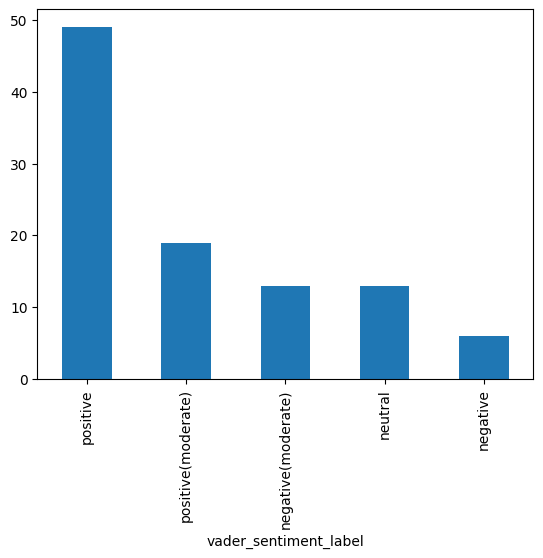

In [18]:
data['vader_sentiment_label'].value_counts().plot.bar()

### Pre-trained Transformer Model

In [19]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [20]:
transformer_labels = []

for review in data['reviewText_clean'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label)
    
data['transformer_sentiment_label'] = transformer_labels
data.head(10)

,index,reviewText,rating,reviewText_clean,vader_sentiment_score,vader_sentiment_label,transformer_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,[POSITIVE]
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,[POSITIVE]
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,[NEGATIVE]
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,[NEGATIVE]
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative(moderate),[NEGATIVE]
5,7277,"Great book packed full with fast cars , crazy ...",4,great book packed full with fast cars crazy h...,0.7269,positive,[POSITIVE]
6,9781,I enjoyed the reader's digest very much. If I ...,4,i enjoyed the readers digest very much if i co...,0.5106,positive,[POSITIVE]
7,4583,This series has been good and I look forward t...,5,this series has been good and i look forward t...,0.7906,positive,[POSITIVE]
8,9797,I just could not get into this book.I all ways...,1,i just could not get into this booki all ways ...,0.0000,neutral,[NEGATIVE]
9,895,it was good to see where Dan and Elle was. And...,4,it was good to see where dan and elle was and ...,0.8107,positive,[POSITIVE]


<Axes: xlabel='transformer_sentiment_label'>

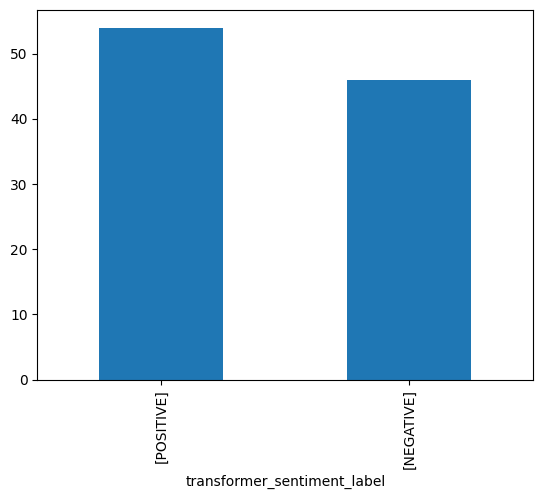

In [21]:
data['transformer_sentiment_label'].value_counts().plot.bar()